In [1]:
import os
import pandas as pd
import numpy as np
import warnings
import pkg_resources
from datetime import datetime as dt, timedelta
from wrf import (to_np, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, interplevel, ll_to_xy)
from wrf import getvar, interplevel, to_np, get_cartopy, latlon_coords
from datetime import datetime
import glob
from netCDF4 import Dataset
import sys
sys.path.insert(1, '/glade/work/ihtam/wrf-stuff/analysis/')
from util.wrf_process import (calc_derive, object_tracking, read_and_write)
from util.ml_preprocess import data_preproc
import gc
from tqdm import tqdm
import xarray as xr
import sys
import pickle
from natsort import natsorted
import proplot as plot
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, to_np, get_cartopy, latlon_coords
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Nimbus Roman', 'Times', 'C059-Roman', 'P052-Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'

def open_pickle(filename):
    with open(filename, "rb") as f:
        loaded_object = pickle.load(f)
    return loaded_object

/glade/derecho/scratch/ihtam/tmp/ipykernel_1162/2879379585.py:5: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Track path
track_memb03 = xr.open_dataset('/glade/work/ihtam/storage/track_avor_850-600.nc')

In [3]:
ctrl_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/ctrl/wrfout_d02_2013-11-0*"))[:29]
miaxi2x_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2idealaxi/wrfout_d02_2013-11-0*"))[:29]
aiaxi2x_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/add_2idealaxi/wrfout_d02_2013-11-0*"))[:29]
mdd_p2f_files =sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:29]
dd_p2f_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/add_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:29]

#sens2x_files =sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/add2wv1N/wrfout_d02_2013-11-0*"))[:29]
#ctrl_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/ctrl/wrfout_d02_2013-11-0*"))[:29]
#minus2x_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/minus_2wv1N/wrfout_d02_2013-11-0*"))[:29]
#dd_p2f_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/add_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:29]
#mdd_p2f_files =sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:29]

ctrl_mslp,miaxi2x_mslp,mdd_p2f_mslp = [],[],[]
dd_p2f_mslp,aiaxi2x_mslp = [],[]
for i in tqdm(range(len(ctrl_files))):
    # read file
    nc_ctrl = Dataset(ctrl_files[i])
    nc_miaxi2x = Dataset(miaxi2x_files[i])
    nc_aiaxi2x = Dataset(aiaxi2x_files[i])
    nc_mdd_p2f2x = Dataset(mdd_p2f_files[i])
    nc_dd_p2f2x = Dataset(dd_p2f_files[i])
    # Target location
    target_lat = track_memb03['clat'][12+i]
    target_lon = track_memb03['clon'][12+i]
    # Compute track indices
    ix, iy = ll_to_xy(nc_ctrl, target_lat, target_lon, timeidx=0) #x, y
    # Read in max reflectivity
    ctrl_slp = getvar(nc_ctrl,'slp')
    miaxi2x_slp = getvar(nc_miaxi2x,'slp')
    aiaxi2x_slp = getvar(nc_aiaxi2x,'slp')
    mdd_p2f_slp = getvar(nc_mdd_p2f2x,'slp')
    dd_p2f_slp = getvar(nc_dd_p2f2x,'slp')
    # Find mslp
    ctrl_mslp.append(float(ctrl_slp[int(iy)-50:int(iy)+50,int(ix)-50:int(ix)+50].min()))
    miaxi2x_mslp.append(float(miaxi2x_slp[int(iy)-50:int(iy)+50,int(ix)-50:int(ix)+50].min()))
    aiaxi2x_mslp.append(float(aiaxi2x_slp[int(iy)-50:int(iy)+50,int(ix)-50:int(ix)+50].min()))
    mdd_p2f_mslp.append(float(mdd_p2f_slp[int(iy)-50:int(iy)+50,int(ix)-50:int(ix)+50].min()))
    dd_p2f_mslp.append(float(dd_p2f_slp[int(iy)-50:int(iy)+50,int(ix)-50:int(ix)+50].min()))

    del ctrl_slp,miaxi2x_slp,aiaxi2x_slp,mdd_p2f_slp,dd_p2f_slp
    gc.collect()

100%|██████████| 29/29 [11:53<00:00, 24.62s/it]


In [3]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 15.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 12.5,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

/glade/derecho/scratch/ihtam/tmp/ipykernel_1162/1606955898.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


In [5]:
def open_pickle(filepath):
    with open(filepath, 'rb') as handle:
        data = pickle.load(handle)
    return data

mslp_dict = open_pickle(f"./store/old/haiyansen_mslp.pkl")

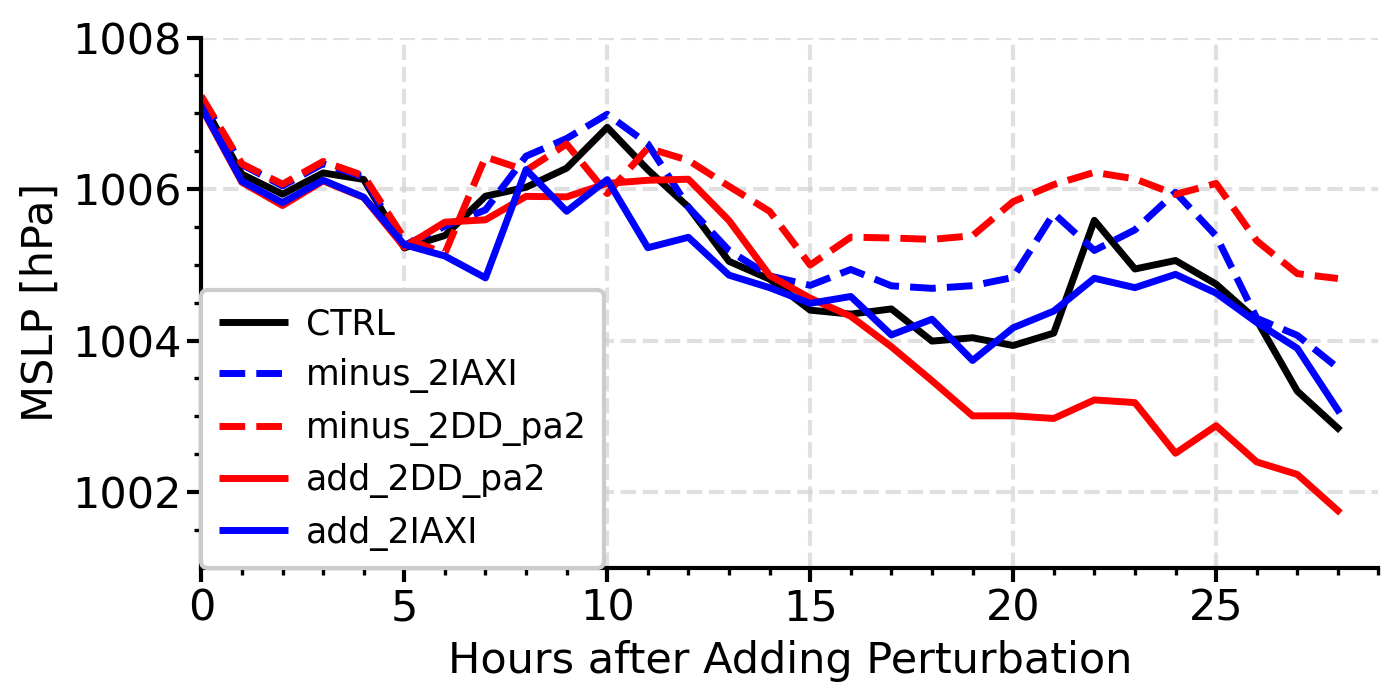

In [14]:
fig, axs = plot.subplots(ncols=1, figsize=(7,3.5), share=False)
axs.plot(mslp_dict['ctrl'],c='k',label='CTRL',lw=2.5)
axs.plot(mslp_dict['miaxi2x'],c='b',ls='--',label='minus_2IAXI',lw=2.5)
axs.plot(mslp_dict['mdd_p2f'],c='r',ls='--',label='minus_2DD_pa2',lw=2.5)
axs.plot(mslp_dict['dd_p2f'],c='r',ls='-',label='add_2DD_pa2',lw=2.5)
axs.plot(mslp_dict['aiaxi2x'],c='b',ls='-',label='add_2IAXI',lw=2.5)
axs.format(xlim=(0,29),ylim=(1001,1008),
           xlabel='Hours after Adding Perturbation', ylabel='MSLP [hPa]')
plt.legend(loc=1,ncols=1)
plt.savefig('./pics/mslp_wrfsens_animate3.png',dpi=400)
plt.show()

In [8]:
mslpdict = {'ctrl':ctrl_mslp,'miaxi2x':miaxi2x_mslp,'mdd_p2f':mdd_p2f_mslp,'dd_p2f':dd_p2f_mslp,'aiaxi2x':aiaxi2x_mslp}
with open(f"./store/haiyansen_mslp.pkl", "wb") as f:
    pickle.dump(mslpdict, f)

In [9]:
ctrl_vmax,miaxi2x_vmax,mdd_p2f_vmax = [],[],[]
dd_p2f_vmax,aiaxi2x_vmax = [],[]
for i in tqdm(range(len(ctrl_files))):
    # read file
    nc_ctrl = Dataset(ctrl_files[i])
    nc_miaxi2x = Dataset(miaxi2x_files[i])
    nc_aiaxi2x = Dataset(aiaxi2x_files[i])
    nc_mdd_p2f2x = Dataset(mdd_p2f_files[i])
    nc_dd_p2f2x = Dataset(dd_p2f_files[i])
    # Target location
    target_lat = track_memb03['clat'][12+i]
    target_lon = track_memb03['clon'][12+i]
    # Compute track indices
    ix, iy = ll_to_xy(nc_ctrl, target_lat, target_lon, timeidx=0) #x, y
    # Read in max reflectivity
    ctrl_slp = np.sqrt(getvar(nc_ctrl,'ua')[0,...]**2+getvar(nc_ctrl,'va')[0,...]**2)
    miaxi2x_slp = np.sqrt(getvar(nc_miaxi2x,'ua')[0,...]**2+getvar(nc_miaxi2x,'va')[0,...]**2)
    aiaxi2x_slp = np.sqrt(getvar(nc_aiaxi2x,'ua')[0,...]**2+getvar(nc_aiaxi2x,'va')[0,...]**2)
    dd_p2f_slp = np.sqrt(getvar(nc_dd_p2f2x,'ua')[0,...]**2+getvar(nc_dd_p2f2x,'va')[0,...]**2)
    mdd_p2f_slp = np.sqrt(getvar(nc_mdd_p2f2x,'ua')[0,...]**2+getvar(nc_mdd_p2f2x,'va')[0,...]**2)
    # Find mslp
    ctrl_vmax.append(float(ctrl_slp[int(iy)-50:int(iy)+50,int(ix)-50:int(ix)+50].max()))
    aiaxi2x_vmax.append(float(aiaxi2x_slp[int(iy)-50:int(iy)+50,int(ix)-50:int(ix)+50].max()))
    miaxi2x_vmax.append(float(miaxi2x_slp[int(iy)-50:int(iy)+50,int(ix)-50:int(ix)+50].max()))
    dd_p2f_vmax.append(float(dd_p2f_slp[int(iy)-50:int(iy)+50,int(ix)-50:int(ix)+50].max()))
    mdd_p2f_vmax.append(float(mdd_p2f_slp[int(iy)-50:int(iy)+50,int(ix)-50:int(ix)+50].max()))

    del ctrl_slp,miaxi2x_slp,aiaxi2x_slp,mdd_p2f_slp,dd_p2f_slp
    gc.collect()

100%|██████████| 29/29 [08:27<00:00, 17.50s/it]


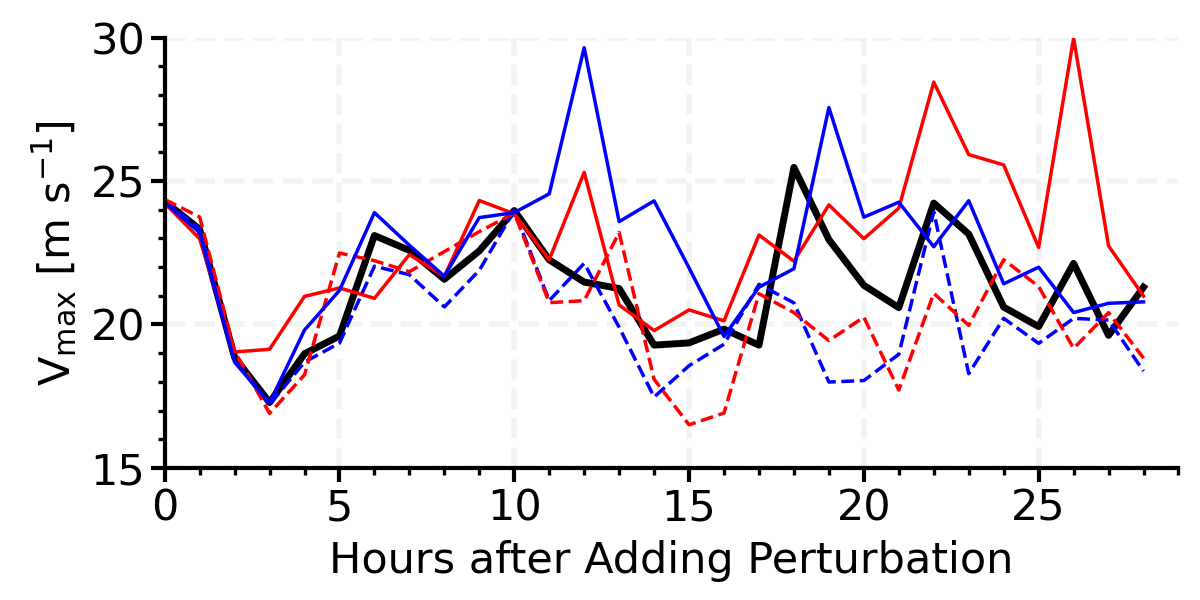

In [16]:
# ProPlot handles subplots with simple syntax
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
axs.plot(ctrl_vmax,c='k',label='CTRL',lw=2.5)
axs.plot(miaxi2x_vmax,c='b',ls='--',label='minus_2IAXI',lw=1.25)
axs.plot(mdd_p2f_vmax,c='r',ls='--',label='minus_2DD_pa2',lw=1.25)
axs.plot(dd_p2f_vmax,c='r',ls='-',label='add_2DD_pa2',lw=1.25)
axs.plot(aiaxi2x_vmax,c='b',ls='-',label='add_2IAXI',lw=1.25)
plt.grid(alpha=0.25,lw=2,ls='--')
plt.ylim(1000,1010)
axs.format(xlim=(0,29),ylim=(15,30),
           xlabel='Hours after Adding Perturbation', ylabel='V$_{max}$ [m s$^{-1}$]')
#plt.legend(loc=2,ncols=2)
plt.savefig('./pics/vmax_wrfsens.png',dpi=400)
plt.show()

In [15]:
vmaxdict = {'ctrl':ctrl_vmax,'miaxi2x':miaxi2x_vmax,'mdd_p2f':mdd_p2f_vmax,'dd_p2f':dd_p2f_vmax,'aiaxi2x':aiaxi2x_vmax}
with open(f"./store/haiyansen_vmax.pkl", "wb") as f:
    pickle.dump(vmaxdict, f)